In [1]:
import tensorflow as tf
from tensorflow.keras import datasets
from keras.models import Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
import matplotlib.pyplot as plt

In [2]:
(X_train, y_train), (X_test, y_test) = datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
X_train.shape

(60000, 28, 28)

In [4]:
X_test.shape

(10000, 28, 28)

In [ ]:
# How to make the data to single scaling by dividing it by 255


In [5]:
# scaling values between 1 and 0
X_train = X_train.reshape((X_train.shape[0],28,28,1))/255.0
X_test = X_test.reshape((X_test.shape[0],28,28,1))/255.0

In [6]:
X_train[:,0]

array([[[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]],

       [[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]],

       [[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]],

       ...,

       [[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]],

       [[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]],

       [[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]]])

In [7]:
# Build the model
model = Sequential()
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Flatten())
model.add(Dense(64,activation='relu'))
model.add(Dense(10,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [10]:
history = model.fit(X_train,y_train,epochs=10,validation_data=(X_test,y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8980 - loss: 0.3244 - val_accuracy: 0.9860 - val_loss: 0.0439
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9850 - loss: 0.0501 - val_accuracy: 0.9863 - val_loss: 0.0387
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9897 - loss: 0.0329 - val_accuracy: 0.9884 - val_loss: 0.0346
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9921 - loss: 0.0227 - val_accuracy: 0.9905 - val_loss: 0.0304
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9947 - loss: 0.0163 - val_accuracy: 0.9906 - val_loss: 0.0299
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9956 - loss: 0.0129 - val_accuracy: 0.9908 - val_loss: 0.0299
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9966 - loss: 0.0104 - val_accuracy: 0.9889 - val_loss: 0.0367
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9972 - loss: 0.0083 -

In [11]:
score = model.evaluate(X_test,y_test)
print("Test Accuracy is ",score[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9889 - loss: 0.0484
Test Accuracy is  0.9908999800682068


In [12]:
from tensorflow.keras.datasets import cifar10

In [13]:
# Load the CIFAR-10 dataset https://www.cs.toronto.edu/~kriz/cifar.html
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [14]:
X_train.shape

(50000, 32, 32, 3)

In [15]:
# Normalize the pixel values to be between 0 and 1
X_train = X_train / 255.0
X_test = X_test / 255.0

In [16]:
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model

In [17]:
# Define the input layer
input_tensor = Input(shape=(32, 32, 3))

# Creating CNN model using the functional API
x = Conv2D(32,(3,3),activation='relu')(input_tensor)
x = MaxPooling2D((2,2))(x)
x = Conv2D(64,(3,3),activation='relu')(x)
x = MaxPooling2D((2,2))(x)
x = Conv2D(64,(3,3),activation='relu')(x)
x = Flatten()(x)
x = Dense(64,activation='relu')(x)
output_tensor = Dense(10,activation='softmax')(x) # 10 is the number of classes in CIFAR-10

model = Model(inputs=input_tensor, outputs=output_tensor)

In [18]:
model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [20]:
model.fit(X_train,y_train,epochs=10,validation_data=(X_test,y_test))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.3426 - loss: 1.7705 - val_accuracy: 0.5315 - val_loss: 1.3140
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5689 - loss: 1.2100 - val_accuracy: 0.6197 - val_loss: 1.0990
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6440 - loss: 1.0119 - val_accuracy: 0.6667 - val_loss: 0.9642
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6830 - loss: 0.9076 - val_accuracy: 0.6805 - val_loss: 0.9261
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7161 - loss: 0.8179 - val_accuracy: 0.6928 - val_loss: 0.8937
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7306 - loss: 0.7635 - val_accuracy: 0.7135 - val_loss: 0.8415
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7539 - loss: 0.7061 - val_accuracy: 0.7226 - val_loss: 0.8287
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7680 - loss: 0.6595 -

In [21]:
score = model.evaluate(X_test,y_test)
print("Test Accuracy is ",score[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7181 - loss: 0.8498
Test Accuracy is  0.7139999866485596


In [22]:
import numpy as np
from tensorflow.keras.models import Model

In [23]:
layer_outputs = [layer.output for layer in model.layers if 'conv' in layer.name]

In [24]:
# Make a prediction with a sample input to define the model's input shape
_ = model.predict(X_test[:1])

# Collect layer outputs after the model is built
layer_outputs = [layer.output for layer in model.layers if 'conv' in layer.name]

activation_model = Model(inputs=model.input,outputs=layer_outputs)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 550ms/step


In [45]:
sample_img = X_test[2].reshape((1,32,32,3))
activations = activation_model.predict(sample_img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


In [38]:
sample_img_1 = X_test[2].reshape((1,32,32,3))
predictions = model.predict(sample_img_1)
predicted_class = np.argmax(predictions)

print("The model predicts the class:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
The model predicts the class: 9


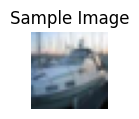

In [39]:
plt.figure(figsize=(1,1))
plt.imshow(sample_img_1.reshape(32, 32, 3))
plt.title("Sample Image")
plt.axis('off')
plt.show()

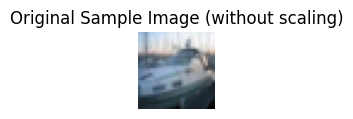

In [41]:
plt.figure(figsize=(1,1))
plt.imshow(X_test[2])
plt.title("Original Sample Image (without scaling)")
plt.axis('off')
plt.show()

In [48]:
first_layer_activation = activations[0]

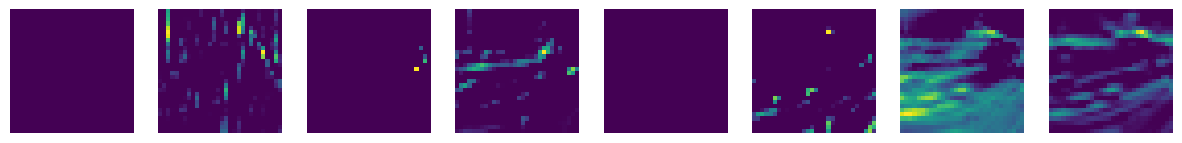

In [49]:
plt.figure(figsize=(15,8))
for i in range(8):
  plt.subplot(1,8,i+1)
  plt.imshow(first_layer_activation[0,:,:,i],cmap='viridis')
  plt.axis('off')
plt.show()

In [ ]:
# Build the model explicitly with a sample input shape
# Assuming the input shape is (32, 32, 3) for CIFAR-10 images
# model.build(input_shape=(None, 32, 32, 3)) # This line is no longer needed as the model from dc9693f2 is already built

activation_model = Model(inputs=model.input, outputs=layer_outputs)

AttributeError: The layer sequential_3 has never been called and thus has no defined input.

In [ ]:
# Get the outputs of the convolutional layers from the successfully built model
layer_outputs = [layer.output for layer in model.layers if 'conv2d' in layer.name]

# Build the model explicitly with a sample input shape
# Assuming the input shape is (32, 32, 3) for CIFAR-10 images
model.build(input_shape=(None, 32, 32, 3))


# Create a model that will return these outputs, given the model input
activation_model = Model(inputs=model.input, outputs=layer_outputs)

AttributeError: The layer sequential_3 has never been called and thus has no defined input.

In [ ]:
# Visualize some examples from the training data
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i])
    # The CIFAR-10 dataset has 10 classes, you can define the class names here
    # plt.xlabel(class_names[y_train[i][0]]) # Uncomment and use after defining class_names
plt.show()

In [ ]:
# Define the class names for the CIFAR-10 dataset
# class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
#                'dog', 'frog', 'horse', 'ship', 'truck'] # Uncomment and use this after defining class_names

In [ ]:
# Build the convolutional base
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
])

# Add Dense layers on top
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(10)) # 10 is the number of classes in CIFAR-10